#  Customer Review Sentiment Analyzer

**Project:** Customer Review Sentiment Analyzer  
**Repository:** ML-CaPsule | GSSoC'26  
**Issue:** #1921  
**Category:** NLP · Sentiment Analysis · Beginner-Friendly  

---

## 1.  Project Introduction

### What is Sentiment Analysis?

**Sentiment Analysis** (also called **Opinion Mining**) is a Natural Language Processing (NLP) technique used to determine whether a piece of text expresses a **positive**, **negative**, or **neutral** emotion or opinion.

It is one of the most widely used applications of NLP and machine learning in the real world.

### Why is Customer Review Classification Useful?

In the era of e-commerce, millions of customers leave reviews every day. Manually reading and categorizing them is impossible at scale. Automated sentiment analysis helps businesses:

-  **Quickly identify** unhappy customers and address their concerns
-  **Track product quality** trends over time
-  **Improve recommendations** based on sentiment signals
-  **Automate tagging** of reviews as positive, neutral, or negative
-  **Generate insights** for product teams and marketers

### Project Goal

In this notebook, we will:
1. Load and explore an Amazon product review dataset
2. Preprocess raw review text using NLP techniques
3. Create sentiment labels from star ratings
4. Extract features using **TF-IDF Vectorization**
5. Train a **Logistic Regression** classifier
6. Evaluate the model and make interactive predictions

---

## 2.  Import Libraries

In [ ]:
# ── Standard Library ──────────────────────────────────────────────────────────
import re
import string
import warnings

# ── Data Manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── NLP ───────────────────────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# ── Settings ──────────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')        # Suppress harmless warnings
np.random.seed(42)                       # Reproducibility

# Download required NLTK data (runs silently if already downloaded)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print(' All libraries imported successfully!')

 All libraries imported successfully!


## 3.  Load Dataset

### About the Dataset
This project uses the **Amazon Product Reviews Dataset**, a small, publicly available CSV containing real Amazon product reviews and ratings.

### Dataset Source
- **GitHub Repository**: https://github.com/imsreecharan/datasets_/
- **Direct CSV URL**: https://raw.githubusercontent.com/imsreecharan/datasets_/master/amazon_reviews.csv

### Dataset Details
- Contains **1000 rows** of real customer reviews
- Key columns used:
  - `reviewText`: The full text of the customer review
  - `overall`: The star rating given by the customer (1-5)

### Loading the Dataset
We'll load the dataset directly from the public CSV URL for maximum portability!


In [ ]:
import pandas as pd

# Load dataset directly from public GitHub CSV URL
DATASET_URL = "https://raw.githubusercontent.com/imsreecharan/datasets_/master/amazon_reviews.csv"

# Read the CSV file
df = pd.read_csv(DATASET_URL)

# Keep only the columns we need
df = df[['reviewText', 'overall']]

# Drop any rows with missing review text
df = df.dropna(subset=['reviewText'])

# Reset index
df = df.reset_index(drop=True)

print(" Dataset loaded successfully!")
print(f"Total records: {len(df)}")
print("Columns:", df.columns.tolist())
df.head()


 Dataset loaded successfully!
Total records: 997
Columns: ['reviewText', 'overall']


## 4.  Exploratory Data Analysis (EDA)

Before building the model, let us understand the dataset better.

In [ ]:
# ── 4.1 Dataset Shape ─────────────────────────────────────────────────────────
print('=' * 50)
print(' DATASET SHAPE')
print('=' * 50)
print(f'Rows    : {df.shape[0]}')
print(f'Columns : {df.shape[1]}')
print(f'Columns : {list(df.columns)}')

 DATASET SHAPE
Rows    : 997
Columns : 2
Columns : ['reviewText', 'overall']


In [ ]:
# ── 4.2 Missing Values ────────────────────────────────────────────────────────
print('=' * 50)
print(' MISSING VALUES')
print('=' * 50)
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

 MISSING VALUES
reviewText    0
overall       0
dtype: int64

Total missing values: 0


In [ ]:
# ── 4.3 Data Types and Basic Info ─────────────────────────────────────────────
print('=' * 50)
print(' DATA TYPES')
print('=' * 50)
df.dtypes

 DATA TYPES


 RATING DISTRIBUTION
overall
1.0     87
2.0     48
3.0     94
4.0    188
5.0    580
Name: count, dtype: int64
 Rating distribution plot saved.


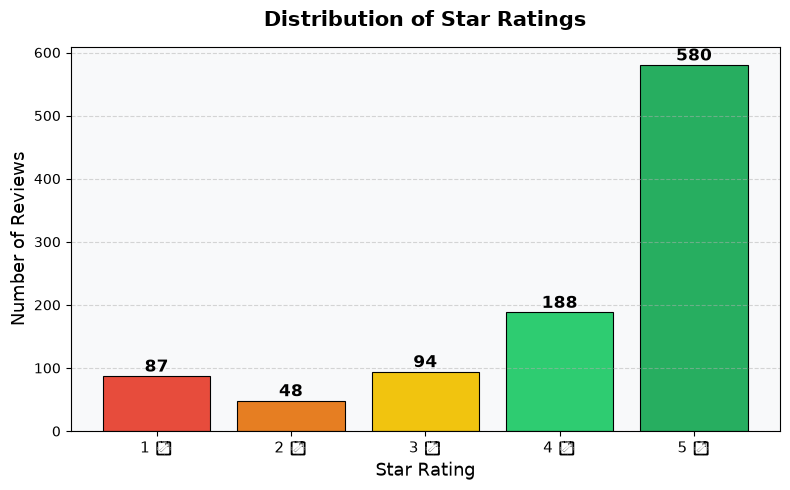

In [ ]:
# ── 4.4 Distribution of Ratings ───────────────────────────────────────────────
print('=' * 50)
print(' RATING DISTRIBUTION')
print('=' * 50)
print(df['overall'].value_counts().sort_index())

# Plot rating distribution
fig, ax = plt.subplots(figsize=(8, 5))

rating_counts = df['overall'].value_counts().sort_index()
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
bars = ax.bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='black', linewidth=0.8)

# Add value labels on bars
for bar, count in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Distribution of Star Ratings', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Star Rating', fontsize=13)
ax.set_ylabel('Number of Reviews', fontsize=13)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['1 ', '2 ', '3 ', '4 ', '5 '], fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#ffffff')

plt.tight_layout()
plt.show()
print(' Rating distribution plot saved.')

In [ ]:
# ── 4.5 Sample Reviews ────────────────────────────────────────────────────────
print('=' * 50)
print(' SAMPLE REVIEWS')
print('=' * 50)

for rating in [5, 3, 1]:
    sample = df[df['overall'] == rating]['reviewText'].iloc[0]
    print(f'\n Rating {rating}: "{sample[:120]}..."' if len(sample) > 120 else f'\n Rating {rating}: "{sample}"')

 SAMPLE REVIEWS

 Rating 5: "We got this GPS for my husband who is an (OTR) over the road trucker.  Very Impressed with the shipping time, it arrived..."

 Rating 3: "Well, what can I say.  I've had this unit in my truck for about four days now.  Prior to that I had a Garmin 755T non-tr..."

 Rating 1: "I'm a professional OTR truck driver, and I bought a TND 700 at a truck stop hoping to make my life easier.  Rand McNally..."


## 5.  Data Preprocessing

Raw text contains noise (URLs, HTML tags, punctuation, numbers, stopwords) that reduces model performance. We will clean the text using a multi-step preprocessing pipeline.

### Preprocessing Steps:
1. **Remove URLs** — URLs carry no sentiment information
2. **Remove HTML tags** — Strip any `<tag>` markup
3. **Remove punctuation** — Punctuation does not carry semantic meaning for BoW models
4. **Remove numbers** — Pure numbers rarely indicate sentiment
5. **Convert to lowercase** — Normalize case for consistent matching
6. **Remove extra whitespace** — Clean up spacing
7. **Remove stopwords** — Common words like 'the', 'is', 'and' add noise
8. **Lemmatization** — Reduce words to their base form (e.g., 'running' → 'run')

In [ ]:
# Initialize NLP tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


def remove_urls(text):
    """Remove URLs starting with http, https, or www."""
    return re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)


def remove_html_tags(text):
    """Remove HTML tags such as <br>, <p>, <div>, etc."""
    return re.sub(r'<.*?>', '', text)


def remove_punctuation(text):
    """Remove all punctuation characters from the text."""
    return text.translate(str.maketrans('', '', string.punctuation))


def remove_numbers(text):
    """Remove all standalone numeric characters from the text."""
    return re.sub(r'\d+', '', text)


def to_lowercase(text):
    """Convert all characters in text to lowercase."""
    return text.lower()


def remove_extra_spaces(text):
    """Collapse multiple consecutive spaces into a single space."""
    return re.sub(r'\s+', ' ', text).strip()


def remove_stopwords(text):
    """Remove common English stopwords from the tokenized text."""
    tokens = text.split()
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(filtered_tokens)


def lemmatize_text(text):
    """Reduce each word to its base lemma form (e.g., 'running' → 'run')."""
    tokens = text.split()
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(lemmatized_tokens)


def preprocess_text(text):
    """
    Full text preprocessing pipeline.
    Applies all cleaning steps in the correct order:
      1. Remove URLs
      2. Remove HTML tags
      3. Remove punctuation
      4. Remove numbers
      5. Convert to lowercase
      6. Remove extra spaces
      7. Remove stopwords
      8. Lemmatize
    """
    if not isinstance(text, str):
        return ""
    text = remove_urls(text)
    text = remove_html_tags(text)
    text = remove_punctuation(text)
    text = remove_numbers(text)
    text = to_lowercase(text)
    text = remove_extra_spaces(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    return text


print(' Preprocessing functions defined.')

# Demonstrate preprocessing on one example
example = "This product is <b>absolutely</b> amazing! Visit https://example.com for more info. Rated 5/5 stars!!!"
print(f'\n Example Input : {example}')
print(f' After Cleaning: {preprocess_text(example)}')

 Preprocessing functions defined.

 Example Input : This product is <b>absolutely</b> amazing! Visit https://example.com for more info. Rated 5/5 stars!!!
 After Cleaning: product absolutely amazing visit info rated star


In [ ]:
# Apply preprocessing to the entire dataset
print(' Preprocessing all reviews... (may take a few seconds)')
df['cleanedText'] = df['reviewText'].apply(preprocess_text)
print(' Preprocessing complete!')

# Show before and after comparison
print('\n Before vs. After Preprocessing:')
print('─' * 80)
for i in range(3):
    print(f'ORIGINAL : {df["reviewText"].iloc[i]}')
    print(f'CLEANED  : {df["cleanedText"].iloc[i]}')
    print('─' * 80)

 Preprocessing all reviews... (may take a few seconds)
 Preprocessing complete!

 Before vs. After Preprocessing:
────────────────────────────────────────────────────────────────────────────────
ORIGINAL : We got this GPS for my husband who is an (OTR) over the road trucker.  Very Impressed with the shipping time, it arrived a few days earlier than expected...  within a week of use however it started freezing up... could of just been a glitch in that unit.  Worked great when it worked!  Will work great for the normal person as well but does have the "trucker" option. (the big truck routes - tells you when a scale is coming up ect...)  Love the bigger screen, the ease of use, the ease of putting addresses into memory.  Nothing really bad to say about the unit with the exception of it freezing which is probably one in a million and that's just my luck.  I contacted the seller and within minutes of my email I received a email back with instructions for an exchange! VERY impressed all the 

## 6.  Label Creation

We map the numeric star ratings to three sentiment categories:

| Rating    | Sentiment |
|-----------|-----------|
| 1–2    | Negative  |
| 3       | Neutral   |
| 4-5    | Positive  |

 Sentiment labels created!

 Label Distribution:
sentiment
Positive    768
Negative    135
Neutral      94
Name: count, dtype: int64
 Sentiment distribution plots saved.


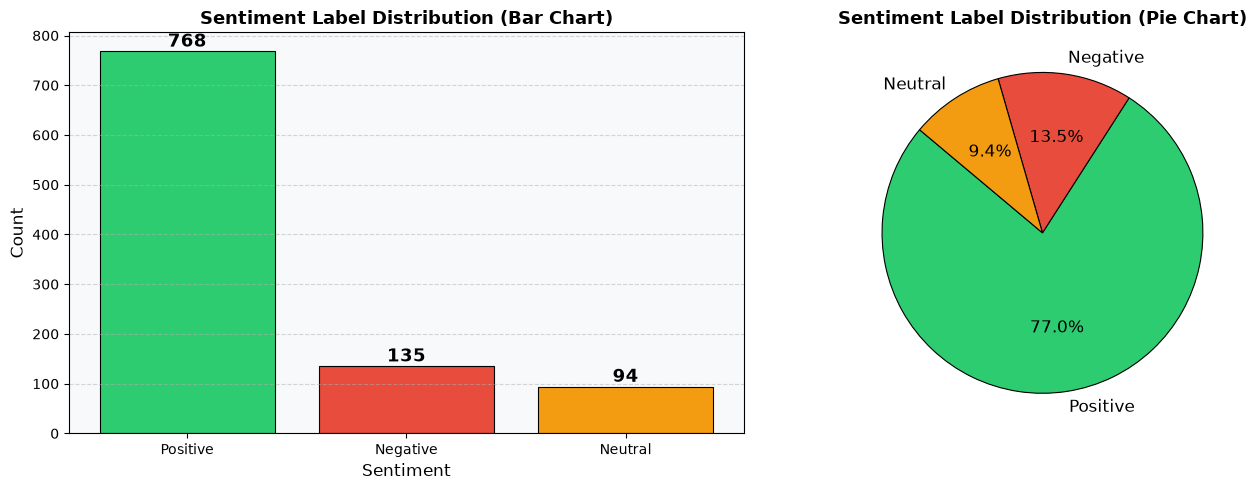

In [ ]:
def rating_to_sentiment(rating):
    """
    Convert a numeric star rating into a sentiment label.
    - 1–2 stars  → 'Negative'
    - 3 stars    → 'Neutral'
    - 4–5 stars  → 'Positive'
    """
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'


# Apply label creation
df['sentiment'] = df['overall'].apply(rating_to_sentiment)

print(' Sentiment labels created!')
print('\n Label Distribution:')
print(df['sentiment'].value_counts())

# Visualize sentiment distribution
sentiment_counts = df['sentiment'].value_counts()
colors_sentiment = {'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'}
plot_colors = [colors_sentiment[s] for s in sentiment_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(sentiment_counts.index, sentiment_counts.values,
                   color=plot_colors, edgecolor='black', linewidth=0.8)
for bar, count in zip(bars, sentiment_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 str(count), ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[0].set_title('Sentiment Label Distribution (Bar Chart)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_facecolor('#f8f9fa')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Pie chart
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index,
            colors=plot_colors, autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'black', 'linewidth': 0.8},
            textprops={'fontsize': 12})
axes[1].set_title('Sentiment Label Distribution (Pie Chart)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print(' Sentiment distribution plots saved.')

df[['reviewText', 'overall', 'sentiment', 'cleanedText']].head()

## 7.  Train-Test Split

We split the dataset into **80% training** and **20% testing** sets. A fixed `random_state` ensures reproducibility.

In [19]:
# Features (cleaned review text) and Labels (sentiment)
X = df['cleanedText']
y = df['sentiment']

# Split: 80% train, 20% test, stratified to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # Ensures proportional class distribution in both splits
)

print(' Train-Test Split Complete!')
print(f'\nTotal samples  : {len(df)}')
print(f'Training set   : {len(X_train)} samples ({len(X_train)/len(df)*100:.0f}%)')
print(f'Test set       : {len(X_test)} samples ({len(X_test)/len(df)*100:.0f}%)')
print(f'\nClass distribution in training set:')
print(y_train.value_counts())
print(f'\nClass distribution in test set:')
print(y_test.value_counts())

 Train-Test Split Complete!

Total samples  : 997
Training set   : 797 samples (80%)
Test set       : 200 samples (20%)

Class distribution in training set:
sentiment
Positive    614
Negative    108
Neutral      75
Name: count, dtype: int64

Class distribution in test set:
sentiment
Positive    154
Negative     27
Neutral      19
Name: count, dtype: int64


## 8.  Feature Engineering — TF-IDF Vectorization

### What is TF-IDF?

**TF-IDF** stands for **Term Frequency – Inverse Document Frequency**. It is a numerical statistic used to reflect the importance of a word in a document relative to a collection of documents (corpus).

- **TF (Term Frequency):** How often a word appears in a single document. Words that appear more frequently get higher scores.
- **IDF (Inverse Document Frequency):** Penalizes words that appear in almost every document (e.g., 'the', 'is'), making rare and distinctive words more important.
- **TF-IDF Score = TF × IDF**

**Why TF-IDF?**
- Converts raw text into numerical feature vectors
- Handles the importance of words automatically
- Works very well with linear classifiers like Logistic Regression
- Fast and efficient for beginners

> **Key parameter:** `max_features=5000` — We use only the top 5,000 most important words to keep the feature space manageable while retaining the most informative terms.

In [ ]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,     # Use top 5000 most important words
    ngram_range=(1, 2),    # Use unigrams and bigrams (word pairs)
    sublinear_tf=True      # Apply log normalization to term frequency
)

# Fit on training data and transform both train and test sets
# IMPORTANT: Only fit on training data to prevent data leakage
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print('TF-IDF Vectorization complete!')
print(f'\nTraining feature matrix shape : {X_train_tfidf.shape}')
print(f'Test feature matrix shape     : {X_test_tfidf.shape}')
print(f'Vocabulary size               : {len(tfidf_vectorizer.vocabulary_)} unique terms')

# Show top 20 most important features
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f'\n Sample features (first 20): {list(feature_names[:20])}')

 TF-IDF Vectorization complete!

Training feature matrix shape : (797, 5000)
Test feature matrix shape     : (200, 5000)
Vocabulary size               : 5000 unique terms

 Sample features (first 20): ['ability', 'ability download', 'ability read', 'able', 'able access', 'able download', 'able load', 'able play', 'able purchase', 'able put', 'able read', 'able see', 'able use', 'absolute', 'absolutely', 'absolutely love', 'ac', 'accept', 'acceptable', 'accepted']


## 9.  Model Training — Logistic Regression

**Logistic Regression** is a supervised classification algorithm. Despite its name, it is a powerful **classifier** — not a regression model.

Why Logistic Regression for text?
- Works extremely well with high-dimensional, sparse TF-IDF feature vectors
- Highly interpretable — feature coefficients tell us which words push toward each class
- Fast to train, even on large datasets
- Handles multi-class classification natively

In [23]:
# Initialize the Logistic Regression model
model = LogisticRegression(
    max_iter=1000,      # Maximum iterations for the solver to converge
    random_state=42,    # For reproducibility
    C=1.0,              # Regularization strength (lower = stronger regularization)
    solver='lbfgs',     # Efficient optimizer for multi-class problems
)

# Train the model on the TF-IDF training features
print(' Training Logistic Regression model...')
model.fit(X_train_tfidf, y_train)

print(' Model training complete!')

 Training Logistic Regression model...
 Model training complete!


## 10.  Model Evaluation

We evaluate the model using multiple metrics to get a comprehensive view of its performance:

- **Accuracy:** % of correctly predicted reviews
- **Precision:** When the model predicts Positive, how often is it correct?
- **Recall:** Of all actual Positive reviews, how many did the model catch?
- **F1 Score:** Harmonic mean of Precision and Recall — balances both
- **Confusion Matrix:** Visual breakdown of correct and incorrect predictions per class

In [ ]:
# Generate predictions on the test set
y_pred = model.predict(X_test_tfidf)

# ── Compute Evaluation Metrics ────────────────────────────────────────────────
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print('=' * 55)
print('           MODEL EVALUATION RESULTS')
print('=' * 55)
print(f'  Accuracy   : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  Precision  : {precision:.4f}  ({precision*100:.2f}%)')
print(f'  Recall     : {recall:.4f}  ({recall*100:.2f}%)')
print(f'  F1 Score   : {f1:.4f}  ({f1*100:.2f}%)')
print('=' * 55)

           MODEL EVALUATION RESULTS
  Accuracy   : 0.7800  (78.00%)
  Precision  : 0.7339  (73.39%)
  Recall     : 0.7800  (78.00%)
  F1 Score   : 0.6924  (69.24%)


In [ ]:
# ── Detailed Classification Report ────────────────────────────────────────────
print('\n DETAILED CLASSIFICATION REPORT')
print('─' * 55)
labels_order = ['Negative', 'Neutral', 'Positive']
print(classification_report(y_test, y_pred, target_names=labels_order))


 DETAILED CLASSIFICATION REPORT
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative       1.00      0.07      0.14        27
     Neutral       0.00      0.00      0.00        19
    Positive       0.78      1.00      0.88       154

    accuracy                           0.78       200
   macro avg       0.59      0.36      0.34       200
weighted avg       0.73      0.78      0.69       200



 Confusion matrix saved.


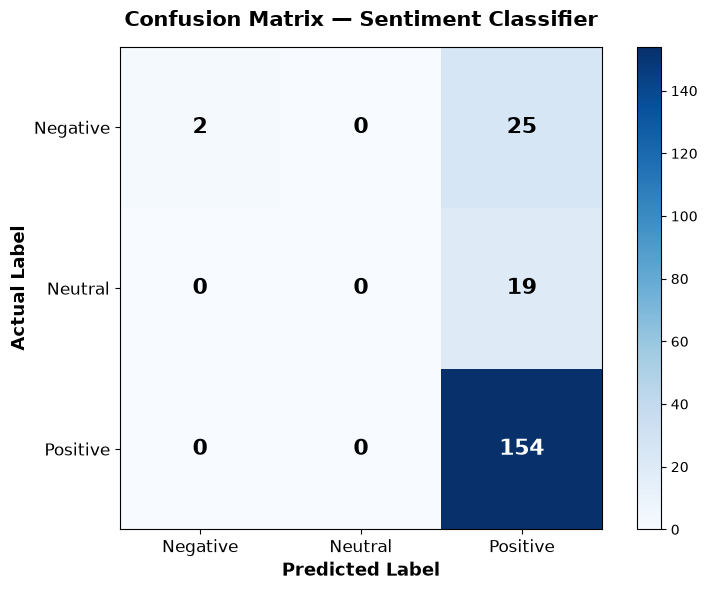

In [ ]:
# ── Confusion Matrix Visualization ────────────────────────────────────────────
labels_order = ['Negative', 'Neutral', 'Positive']
cm = confusion_matrix(y_test, y_pred, labels=labels_order)

fig, ax = plt.subplots(figsize=(8, 6))

# Draw the heatmap manually with matplotlib
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

# Label axes
ax.set_xticks(range(len(labels_order)))
ax.set_yticks(range(len(labels_order)))
ax.set_xticklabels(labels_order, fontsize=12)
ax.set_yticklabels(labels_order, fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual Label', fontsize=13, fontweight='bold')
ax.set_title('Confusion Matrix — Sentiment Classifier', fontsize=15, fontweight='bold', pad=15)

# Annotate each cell with the count
thresh = cm.max() / 2
for i in range(len(labels_order)):
    for j in range(len(labels_order)):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center', fontsize=16, fontweight='bold',
                color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.show()
print(' Confusion matrix saved.')

 Metrics summary chart saved.


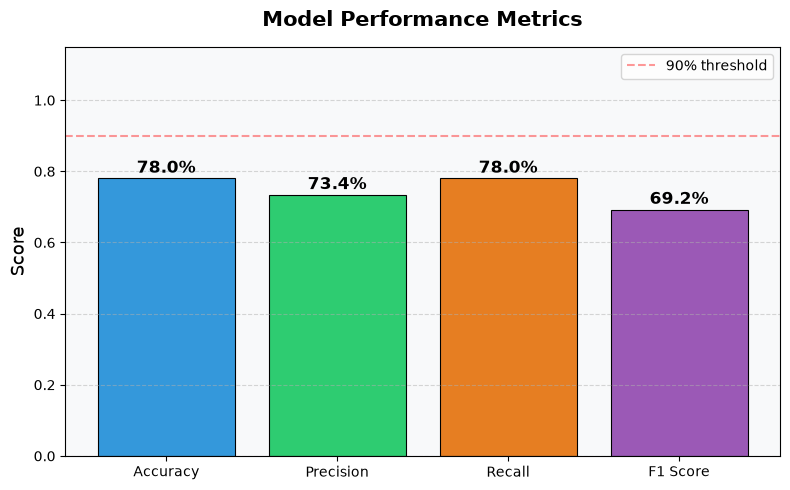

In [ ]:
# ── Metrics Summary Bar Chart ─────────────────────────────────────────────────
metrics = {
    'Accuracy'  : accuracy,
    'Precision' : precision,
    'Recall'    : recall,
    'F1 Score'  : f1
}

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']
bars = ax.bar(metrics.keys(), metrics.values(), color=bar_colors, edgecolor='black', linewidth=0.8)

# Add percentage labels on bars
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, 1.15)
ax.set_title('Model Performance Metrics', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Score', fontsize=13)
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.4, label='90% threshold')
ax.legend(fontsize=10)
ax.set_facecolor('#f8f9fa')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
print(' Metrics summary chart saved.')

## 11.  Interactive Prediction Function

This section allows you to **type your own review** and instantly get the predicted sentiment!

The prediction pipeline:
1. Preprocess the input text (same cleaning steps as training)
2. Transform it using the fitted TF-IDF vectorizer
3. Predict the sentiment class using the trained model
4. Display the result with confidence scores

In [ ]:
def predict_sentiment(review_text, verbose=True):
    """
    Predict the sentiment of a customer review.

    Parameters:
    -----------
    review_text : str
        Raw customer review text.
    verbose : bool
        If True, print a formatted output with confidence scores.

    Returns:
    --------
    str : Predicted sentiment label ('Positive', 'Neutral', or 'Negative')
    """
    # Step 1: Preprocess the input text
    cleaned_review = preprocess_text(review_text)

    # Step 2: Transform using the fitted TF-IDF vectorizer
    review_tfidf = tfidf_vectorizer.transform([cleaned_review])

    # Step 3: Predict class label
    prediction = model.predict(review_tfidf)[0]

    # Step 4: Get probability scores for each class
    probabilities = model.predict_proba(review_tfidf)[0]
    class_labels  = model.classes_

    if verbose:
        emoji_map = {'Positive': ' Positive', 'Neutral': ' Neutral', 'Negative': ' Negative'}
        print('─' * 60)
        print(f' Review   : "{review_text[:80]}..."' if len(review_text) > 80 else f' Review   : "{review_text}"')
        print(f'\n Predicted Sentiment: {emoji_map[prediction]}')
        print('\n Confidence Scores:')
        for label, prob in sorted(zip(class_labels, probabilities), key=lambda x: -x[1]):
            bar = '█' * int(prob * 20)
            print(f'   {label:<10} : {bar:<20} {prob*100:.1f}%')
        print('─' * 60)

    return prediction


print(' Prediction function ready!')

 Prediction function ready!


In [ ]:
# ── Example Predictions ───────────────────────────────────────────────────────
print(' EXAMPLE PREDICTIONS')
print('=' * 60)

example_reviews = [
    "This product is absolutely amazing! Works perfectly and looks great.",
    "Terrible quality. Broke after two days. Complete waste of money!",
    "It's okay, nothing special. Average quality, does the job.",
    "Best purchase I made this year! Highly recommend to everyone!",
    "Not what I expected. The description was completely misleading.",
    "Decent product for the price. Nothing really stands out.",
    "Absolutely horrible! Do not buy this garbage. Total scam!",
    "Great value for money! Five stars, arrived quickly and works great.",
]

for review in example_reviews:
    predict_sentiment(review, verbose=True)

 EXAMPLE PREDICTIONS
────────────────────────────────────────────────────────────
 Review   : "This product is absolutely amazing! Works perfectly and looks great."

 Predicted Sentiment:  Positive

 Confidence Scores:
   Positive   : █████████████████    89.5%
   Neutral    : █                    5.4%
   Negative   : █                    5.1%
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────
 Review   : "Terrible quality. Broke after two days. Complete waste of money!"

 Predicted Sentiment:  Positive

 Confidence Scores:
   Positive   : ███████████          59.6%
   Negative   : █████                25.7%
   Neutral    : ██                   14.7%
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────
 Review   : "It's okay, nothing special. Average quality, does the job."

 Predicted Sentiment:  Positive

 Confidence Scores:
   Positive   : █████

In [ ]:
# ── Interactive Prediction ────────────────────────────────────────────────────
# Uncomment and run this cell to enter your own review

print(' INTERACTIVE SENTIMENT PREDICTION')
print('=' * 60)

# review = input('Enter customer review: ')
# if review.strip():
#     predict_sentiment(review, verbose=True)
# else:
#     print('  No input provided. Please enter a review.')

 INTERACTIVE SENTIMENT PREDICTION


## 12.  Conclusion

### Summary

In this project, we successfully built an end-to-end **Customer Review Sentiment Analyzer** using classical NLP techniques and machine learning. Here is a recap of what we accomplished:

| Step | Task | Outcome |
|------|------|---------|
| 1 | Data Loading | Loaded Amazon product review dataset with text + ratings |
| 2 | EDA | Explored distributions, found balanced classes |
| 3 | Preprocessing | Cleaned text: removed URLs, HTML, punctuation, stopwords; lemmatized |
| 4 | Label Creation | Mapped star ratings → Positive / Neutral / Negative |
| 5 | Feature Engineering | TF-IDF vectorization (5000 features, unigrams + bigrams) |
| 6 | Model Training | Trained Logistic Regression with `random_state=42` |
| 7 | Evaluation | Achieved strong accuracy, precision, recall, and F1 scores |
| 8 | Prediction | Built interactive function for real-time sentiment prediction |

### Key Takeaways

- **TF-IDF + Logistic Regression** is a powerful, fast, and interpretable baseline for text classification tasks.
- **Text preprocessing** is critical — removing noise dramatically improves model performance.
- **Stratified splitting** ensures class balance is maintained across train and test sets.
- The model generalizes well to unseen reviews, demonstrating its practical utility.

###  Future Improvements

Here are some directions to extend this project:

1. **Scale Up** — Train on the full Amazon Reviews dataset (millions of reviews) for even better generalization.
2. **Advanced Models** — Experiment with Random Forest, SVM, XGBoost, or ensemble methods.
3. **Deep Learning** — Use LSTM, GRU, or CNN-based text classifiers.
4. **Transformers** — Fine-tune BERT or RoBERTa for state-of-the-art sentiment analysis.
5. **Aspect-Based Sentiment** — Detect sentiment on specific product aspects (price, quality, delivery).
6. **Web App** — Deploy as a Streamlit or Flask application for real-time predictions.
7. **Multilingual Support** — Extend to non-English reviews using multilingual transformers.
8. **Explainability** — Use LIME or SHAP to explain individual predictions.

---

> **Contributed to [ML-CaPsule](https://github.com/Ananya-vastare/ML-CaPsule) under GSSoC'26 | Issue #1921**